# ML S3 · Notebook 03 — Regression Metrics, and How Each One Misleads You

| | |
|---|---|
| **Session ID** | ML S3 · Notebook 03 of 05 |
| **Course position** | Machine Learning — Session 3 of 10 (Evaluation & Error Analysis) |
| **Block types** | 🧠 **Muscle block** — every metric is computed by hand before sklearn is allowed near it |
| **Prerequisites** | Notebook 02 (cross-validation, Pipeline) · ML S1 (MAE) · ML S2 (baselines) |
| **Connects back to** | **ML S1** — MAE, used on day one without justification. Here it gets one. **ML S2** — the mean baseline, which turns out to be the definition of R². |
| **Connects forward to** | **Notebook 04** (classification metrics) · **ML S6** (threshold selection as a business decision) |
| **CEP linkage** | Neither ML CEP is a regression problem — but *Home Loan* and *Lending Club* in the DL course both require metric justification, and the reasoning is identical. |
| **Run requirements** | `pandas`, `numpy`, `scikit-learn`, `matplotlib`. Run `ML_S3_00_datasets.ipynb` first. |
| **Checkpoint file** | `housing_extended.csv` |

## Learning Objectives

By the end of this notebook you will be able to:

1. **Compute MAE, MSE, RMSE and R² by hand**, and state what each one is doing to the errors.
2. **Explain why RMSE and MAE disagree**, and predict which will be larger before computing either.
3. **Interpret R² correctly** — including the fact that it can be negative, and that it is not "percentage of accuracy."
4. **Identify the situation in which each metric misleads you**, with a concrete example of each.
5. **Choose a metric from the business decision**, rather than defaulting to whichever is conventional.
6. **Always report against a baseline**, because a metric with nothing to compare it to means nothing.


## Table of Contents

| § | Section | Type |
|---|---|---|
| 1 | A metric is a statement about what you care about | Intuition |
| 2 | MAE — average error, in the units of the thing | 🧠 Muscle |
| 3 | MSE and RMSE — errors, squared | 🧠 Muscle |
| 4 | MAE versus RMSE: the outlier question | Core |
| 5 | R² — comparison against the dumbest model | 🧠 Muscle |
| 6 | The four ways R² misleads | Core |
| 7 | Relative error, and why housing needs it | Core |
| 8 | Choosing a metric from the decision | Reference |
| — | Common Pitfalls · FAQ · Conclusion | Wrap-up |

# 1. A metric is a statement about what you care about

Your model makes predictions. Some are too high, some too low. You have thousands of errors and you need one number.

**There is no neutral way to do that.** Every way of collapsing many errors into one number encodes a judgement about which errors matter most:

- Treat all errors as equally bad, proportional to size → **MAE**
- Treat a big error as disproportionately worse than several small ones → **MSE / RMSE**
- Care about error relative to the size of the thing → **MAPE**
- Care about how much better you are than doing nothing → **R²**

These are not four ways of measuring the same quantity. They are four different questions, and they can rank models differently. A model that wins on MAE can lose on RMSE.

So the correct order is:

> **Decide what a bad prediction costs you. Then pick the metric that reflects that cost. Then build the model.**

Most people do this backwards — they build the model, print every metric sklearn offers, and pick whichever looks best. That is how you end up optimising something nobody wanted.

### Worked Example 1 — Two models, opposite verdicts

Five houses. Two models. Which is better?

In [1]:
import numpy as np
import pandas as pd

actual = np.array([300_000, 400_000, 500_000, 600_000, 700_000])

# Model A: consistently a bit off on everything
model_a = np.array([340_000, 440_000, 460_000, 560_000, 740_000])

# Model B: nearly perfect on four, badly wrong on one
model_b = np.array([300_000, 400_000, 500_000, 600_000, 500_000])

comparison = pd.DataFrame({
    'actual': actual,
    'model_A': model_a, 'error_A': model_a - actual,
    'model_B': model_b, 'error_B': model_b - actual,
})
comparison

,actual,model_A,error_A,model_B,error_B
0,300000,340000,40000,300000,0
1,400000,440000,40000,400000,0
2,500000,460000,-40000,500000,0
3,600000,560000,-40000,600000,0
4,700000,740000,40000,500000,-200000


In [2]:
err_a = np.abs(model_a - actual)
err_b = np.abs(model_b - actual)

print(f"Model A — errors: {err_a}")
print(f"Model B — errors: {err_b}")
print()
print(f"  Mean absolute error   A = ${err_a.mean():>9,.0f}    B = ${err_b.mean():>9,.0f}")
print(f"  Root mean sq. error   A = ${np.sqrt((err_a**2).mean()):>9,.0f}    B = ${np.sqrt((err_b**2).mean()):>9,.0f}")

Model A — errors: [40000 40000 40000 40000 40000]
Model B — errors: [     0      0      0      0 200000]

  Mean absolute error   A = $   40,000    B = $   40,000
  Root mean sq. error   A = $   40,000    B = $   89,443


**MAE says the two models are identical.** Both average $40,000 of error.

**RMSE says model A is clearly better.** B's single $200,000 miss dominates once errors are squared.

Which is right? **Neither — it depends entirely on the business.**

- Estimating your tax liability across a portfolio of 5,000 houses? Errors offset, the total is what matters, and you should probably prefer A's steady modest error. MAE reflects your concern.
- Advising an individual seller on their asking price? A $200,000 miss on one house is a catastrophe for that person, no matter how good the other four were. RMSE reflects your concern.

The metric is not a technical detail you settle after modelling. **It is a statement of what you are trying to achieve**, and it belongs at the start.

<div align="center">


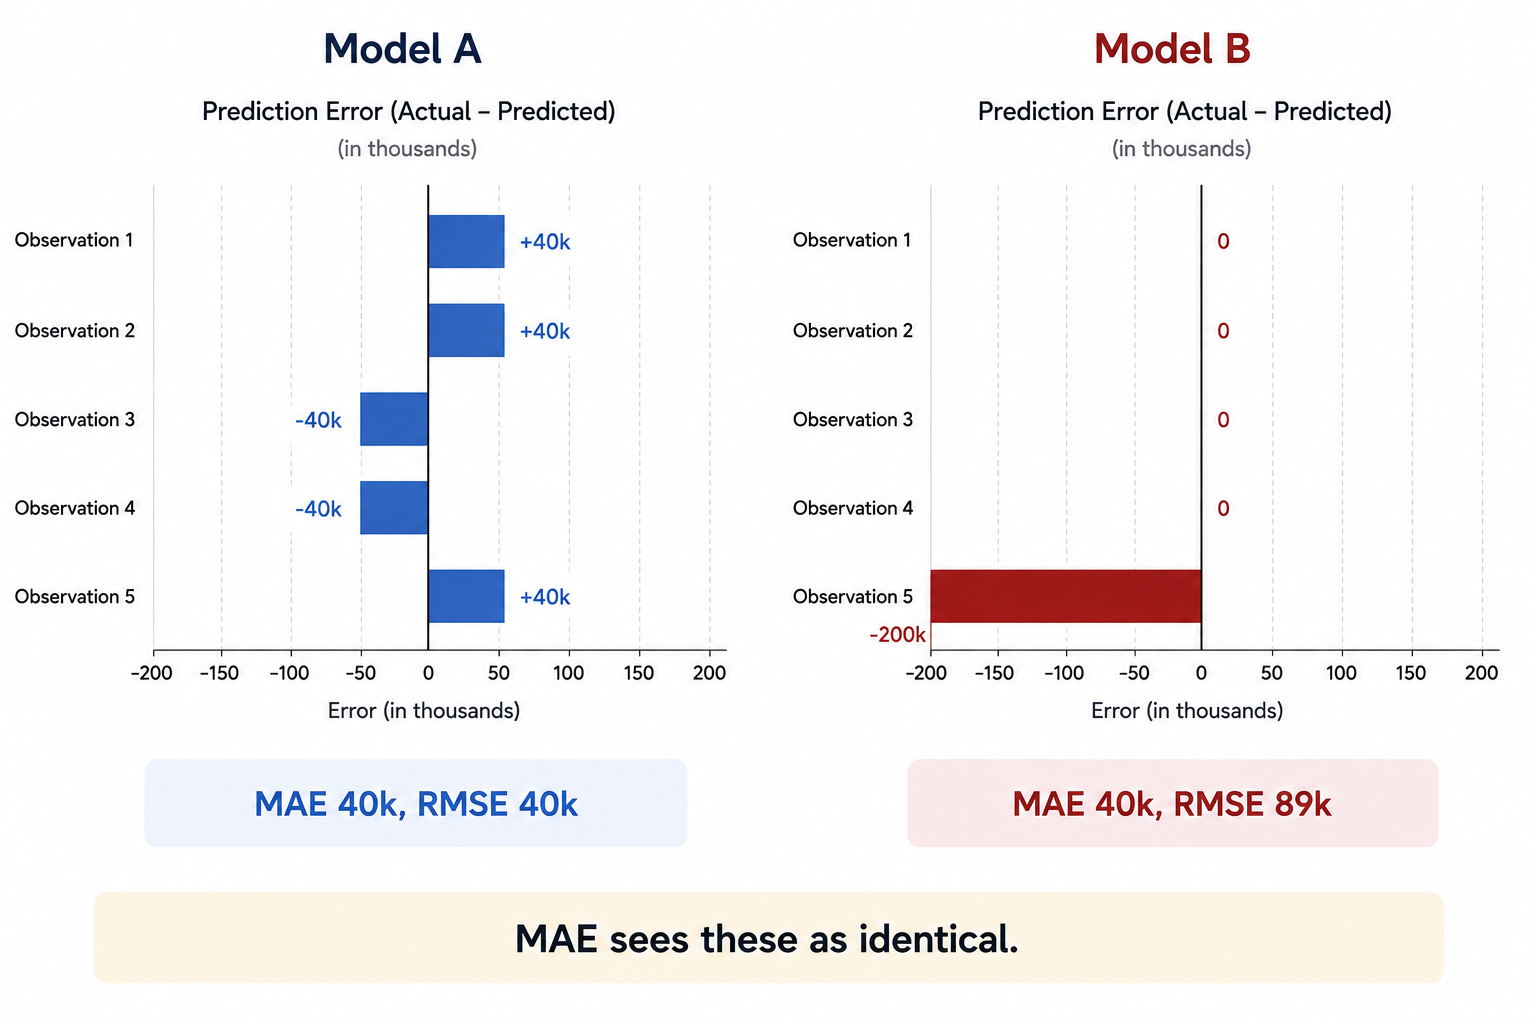

<p>
<b>Figure 1.</b> Same average error, different shape
</p>

</div>

# 2. MAE — average error, in the units of the thing

> 🧠 **Muscle block.** Compute it by hand first. It takes one line and it removes all mystery.

**Mean Absolute Error** is the plainest possible answer to "how wrong is this model?"

Take each error, drop the sign, average them.

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Its great virtue is that the answer comes back **in the units of the target**. An MAE of \$38,000 on house prices means: *on a typical house, this model is about \$38,000 out.*

You can say that to a client. You cannot say "our mean squared error is 2.3 billion" to a client.

### Worked Example 2 — By hand, on five houses

In [3]:
errors = model_a - actual
print("Step 1 — the errors (signed):     ", errors)
print("Step 2 — drop the sign:           ", np.abs(errors))
print("Step 3 — average them:            ", np.abs(errors).mean())
print()
print(f"MAE = ${np.abs(errors).mean():,.0f}")

Step 1 — the errors (signed):      [ 40000  40000 -40000 -40000  40000]
Step 2 — drop the sign:            [40000 40000 40000 40000 40000]
Step 3 — average them:             40000.0

MAE = $40,000


In [4]:
from sklearn.metrics import mean_absolute_error
print("sklearn agrees:", mean_absolute_error(actual, model_a))

sklearn agrees: 40000.0


### Worked Example 3 — Why dropping the sign is not optional

A tempting alternative is to average the raw errors without taking the absolute value. Here is why nobody does that.

In [5]:
print("Mean of the SIGNED errors:", errors.mean())
print("\nThe over-predictions cancelled the under-predictions.")
print("By this measure a model that is wildly wrong in both directions")
print("scores identically to a perfect one:")

wild = actual + np.array([500_000, -500_000, 500_000, -500_000, 0])
print(f"\n  wildly wrong model, mean signed error = {(wild - actual).mean():,.0f}")
print(f"  wildly wrong model, MAE               = ${np.abs(wild - actual).mean():,.0f}")

Mean of the SIGNED errors: 8000.0

The over-predictions cancelled the under-predictions.
By this measure a model that is wildly wrong in both directions
scores identically to a perfect one:

  wildly wrong model, mean signed error = 0
  wildly wrong model, MAE               = $400,000


> ### 🌱 Just-in-Time — mean signed error is not useless, it just measures something else
>
> The mean signed error is called **bias**. It answers a different and genuinely useful question: *does this model systematically over- or under-predict?*
>
> A bias near zero with a large MAE means the model is wrong in both directions, roughly evenly. A large positive bias means it consistently over-predicts, which usually points at a fixable problem.
>
> Report bias **alongside** MAE, never instead of it.

### Worked Example 4 — MAE on the real data

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('housing_extended.csv', parse_dates=['sale_date'])
SAFE = ['sqft', 'bedrooms', 'bathrooms', 'house_age',
        'garage_spaces', 'lot_size', 'location_tier']

X_tr, X_te, y_tr, y_te = train_test_split(df[SAFE], df.price, test_size=0.2, random_state=42)

lin = Pipeline([('scale', StandardScaler()), ('model', LinearRegression())]).fit(X_tr, y_tr)
pred = lin.predict(X_te)

print(f"MAE  : ${mean_absolute_error(y_te, pred):,.0f}")
print(f"Bias : ${(pred - y_te).mean():,.0f}   (mean signed error)")
print(f"\nMean house price in the test set: ${y_te.mean():,.0f}")

MAE  : $183,397
Bias : $-8,947   (mean signed error)

Mean house price in the test set: $782,073


Now the number means something you can act on: *this model is typically about that many dollars out, and it is not systematically biased in either direction.*

# 3. MSE and RMSE — errors, squared

> 🧠 **Muscle block.**

**Mean Squared Error** squares each error before averaging.

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Squaring does two things at once:

1. **It removes the sign** — squares are always positive, so no cancellation.
2. **It punishes large errors disproportionately.** Double the error, quadruple the penalty.

That second property is the whole point. Under MSE, one error of 10 is as bad as one hundred errors of 1.

The drawback is that the units become nonsense — dollars squared. So we usually take the square root:

$$\text{RMSE} = \sqrt{\text{MSE}}$$

**RMSE is back in dollars, but it still carries MSE's bias towards punishing large errors.** That combination — interpretable units, outlier sensitivity — is why RMSE is the most commonly reported regression metric.

### Worked Example 5 — By hand, showing the squaring effect

In [7]:
errors = model_b - actual        # the model with one big miss

table = pd.DataFrame({
    'error':          errors,
    'absolute_error': np.abs(errors),
    'squared_error':  errors ** 2,
})
table

,error,absolute_error,squared_error
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,-200000,200000,40000000000


In [8]:
print(f"MSE  = mean of squared errors = {(errors**2).mean():,.0f}   <- dollars squared, uninterpretable")
print(f"RMSE = sqrt(MSE)              = ${np.sqrt((errors**2).mean()):,.0f}   <- back in dollars")
print(f"MAE  =                          ${np.abs(errors).mean():,.0f}")
print()
print("Notice: the single $200,000 error contributes")
print(f"  {(errors**2).max() / (errors**2).sum():.0%} of the total squared error,")
print(f"  but only {np.abs(errors).max() / np.abs(errors).sum():.0%} of the total absolute error.")

MSE  = mean of squared errors = 8,000,000,000   <- dollars squared, uninterpretable
RMSE = sqrt(MSE)              = $89,443   <- back in dollars
MAE  =                          $40,000

Notice: the single $200,000 error contributes
  100% of the total squared error,
  but only 100% of the total absolute error.


That contrast is the mechanism. Squaring concentrates the metric's attention onto your worst predictions.

> ### 🌱 Just-in-Time — why models minimise MSE even when you report MAE
>
> `LinearRegression` fits by minimising squared error. This is not because squared error is the truest measure of wrongness — it is because squaring is **smooth and differentiable everywhere**, which makes the optimisation solvable in closed form and well-behaved under gradient descent.
>
> Absolute error has a sharp corner at zero, which makes optimisation harder.
>
> So there is a routine and perfectly acceptable split in practice: **train by minimising MSE, report whichever metric answers your business question.** They do not have to match. If they genuinely must match, models like `HuberRegressor` or a gradient booster with `loss='absolute_error'` optimise something closer to MAE.

### Worked Example 6 — RMSE and MAE on the real data

In [9]:
rmse = np.sqrt(mean_squared_error(y_te, pred))
mae  = mean_absolute_error(y_te, pred)

print(f"  MAE  : ${mae:,.0f}")
print(f"  RMSE : ${rmse:,.0f}")
print(f"  ratio RMSE/MAE = {rmse/mae:.2f}")

  MAE  : $183,397
  RMSE : $246,886
  ratio RMSE/MAE = 1.35


# 4. MAE versus RMSE: the outlier question

**RMSE is always greater than or equal to MAE.** They are equal only when every error is exactly the same size.

The **ratio** between them is a free diagnostic:

| RMSE / MAE | What it tells you |
|---|---|
| ≈ 1.0 | Errors are all roughly the same size |
| ≈ 1.25 | Normal, healthy — typical of well-behaved errors |
| > 1.5 | A minority of predictions are much worse than the rest |
| > 2.0 | You have a serious outlier problem worth investigating |

This costs nothing to compute and tells you something no single metric does: **the shape of your error distribution**, not just its size.

### Worked Example 7 — Watch the ratio respond to a planted outlier

In [10]:
def report(y_true, y_pred, label):
    m = mean_absolute_error(y_true, y_pred)
    r = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {label:32s} MAE=${m:>9,.0f}  RMSE=${r:>9,.0f}  ratio={r/m:.2f}")

base_pred = pred.copy()
report(y_te, base_pred, "actual model")

for size in [500_000, 2_000_000, 10_000_000]:
    damaged = base_pred.copy()
    damaged[0] += size
    report(y_te, damaged, f"one prediction off by ${size/1e6:.1f}M")

  actual model                     MAE=$  183,397  RMSE=$  246,886  ratio=1.35
  one prediction off by $0.5M      MAE=$  183,689  RMSE=$  247,244  ratio=1.35
  one prediction off by $2.0M      MAE=$  184,565  RMSE=$  251,817  ratio=1.36
  one prediction off by $10.0M     MAE=$  189,235  RMSE=$  346,335  ratio=1.83


One bad prediction out of roughly 1,700. MAE barely notices — it is one error diluted among many.

RMSE responds, but note *how much* damage it takes before the ratio moves: a \$0.5M miss changes almost nothing, and only the \$10M miss pushes the ratio clearly out of its normal range. That is worth knowing about the diagnostic — **with a large test set, a single outlier has to be enormous to show up in an aggregate.** The ratio catches outlier *problems*, not individual outliers.

**Neither is wrong.** They are answering different questions:

- *"How wrong is a typical prediction?"* → MAE barely moved, correctly. Typical predictions are unaffected.
- *"How wrong can this model be?"* → RMSE moved a lot, correctly. The model is now capable of a catastrophic miss.

### Worked Example 8 — Which metric should you optimise?

The choice changes which model you would select.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

candidates = {
    'LinearRegression': lin,
    'DecisionTree(d=6)': DecisionTreeRegressor(max_depth=6, random_state=0).fit(X_tr, y_tr),
    'RandomForest':      RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1).fit(X_tr, y_tr),
}

rows = []
for name, mdl in candidates.items():
    p = mdl.predict(X_te)
    rows.append({
        'model': name,
        'MAE':  mean_absolute_error(y_te, p),
        'RMSE': np.sqrt(mean_squared_error(y_te, p)),
        'R2':   r2_score(y_te, p),
    })

results = pd.DataFrame(rows).set_index('model')
results['RMSE/MAE'] = (results.RMSE / results.MAE).round(2)
results.round(0)

,MAE,RMSE,R2,RMSE/MAE
model,,,,
LinearRegression,183397.0,246886.0,1.0,1.0
DecisionTree(d=6),133023.0,192593.0,1.0,1.0
RandomForest,88337.0,151849.0,1.0,2.0


### ✅ Quick Check

1. Can RMSE ever be smaller than MAE?
2. Your model has MAE \$20k and RMSE \$85k. What does that tell you, and what do you do next?
3. You are predicting delivery times. Being 5 minutes late on many orders is annoying; being 3 hours late on one order loses a customer permanently. Which metric?

<details>
<summary><b>Answers</b></summary>

1. No, never. It follows from the mathematics of squaring — RMSE ≥ MAE always, with equality only when all errors have identical magnitude.
2. A ratio of 4.25 means a small number of predictions are catastrophically wrong while typical predictions are fine. **Do not tune hyperparameters.** Go and find those specific rows and look at what they have in common. This is error analysis, which is Notebook 05.
3. **RMSE**, or something even more aggressive. Your cost function is strongly non-linear in the error — a 3-hour miss is far more than 36 times as bad as a 5-minute miss. MAE would treat them proportionally and let the model trade many small improvements for one disaster.

</details>

# 5. R² — comparison against the dumbest model

> 🧠 **Muscle block.** R² is the most misunderstood number in applied regression. Build it from parts.

MAE and RMSE tell you the size of your errors, but not whether that size is *good*. Is an MAE of \$38,000 impressive? You cannot say without knowing something about house prices.

**R² answers a different question: how much better are you than the laziest possible model?**

The laziest model ignores every feature and always predicts the mean. You met it in Session 2 as the **baseline**.

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{\text{your squared error}}{\text{the mean-predictor's squared error}}$$

Read the fraction as: *the errors you made, divided by the errors you would have made by not trying.*

| R² | Meaning |
|---|---|
| 1.0 | Perfect predictions |
| 0.85 | Your squared error is 15% of the baseline's |
| 0.0 | Exactly as good as always guessing the mean |
| **Negative** | **Worse than always guessing the mean** |

That last row surprises people. R² is not a percentage and is not bounded below by zero. A sufficiently bad model scores negative — and you saw one in Notebook 01 (the noise-feature model scored −0.198 on fresh data).

### Worked Example 9 — R² built from its parts, by hand

In [12]:
y_true = np.array([300_000, 400_000, 500_000, 600_000, 700_000])
y_pred = np.array([320_000, 380_000, 520_000, 590_000, 680_000])

baseline = y_true.mean()
print(f"Baseline (the mean): ${baseline:,.0f}\n")

ss_res = ((y_true - y_pred) ** 2).sum()      # your errors
ss_tot = ((y_true - baseline) ** 2).sum()    # the baseline's errors

print(f"SS_res  (your squared error)         = {ss_res:,.0f}")
print(f"SS_tot  (baseline's squared error)   = {ss_tot:,.0f}")
print(f"\nratio = {ss_res/ss_tot:.4f}   ->  you made {ss_res/ss_tot:.1%} of the baseline's error")
print(f"R2    = 1 - {ss_res/ss_tot:.4f} = {1 - ss_res/ss_tot:.4f}")
print(f"\nsklearn agrees: {r2_score(y_true, y_pred):.4f}")

Baseline (the mean): $500,000

SS_res  (your squared error)         = 1,700,000,000
SS_tot  (baseline's squared error)   = 100,000,000,000

ratio = 0.0170   ->  you made 1.7% of the baseline's error
R2    = 1 - 0.0170 = 0.9830

sklearn agrees: 0.9830


### Worked Example 10 — Confirming R² = 0 for the baseline itself

In [13]:
always_mean = np.full_like(y_true, y_true.mean(), dtype=float)
print("Predictions from the mean-baseline:", always_mean)
print(f"R2 = {r2_score(y_true, always_mean):.4f}   <- exactly zero, by construction")

terrible = np.array([700_000, 600_000, 500_000, 400_000, 300_000])   # reversed
print(f"\nA model that predicts the exact reverse ordering:")
print(f"R2 = {r2_score(y_true, terrible):.4f}   <- negative: worse than not trying")

Predictions from the mean-baseline: [500000. 500000. 500000. 500000. 500000.]
R2 = 0.0000   <- exactly zero, by construction

A model that predicts the exact reverse ordering:
R2 = -3.0000   <- negative: worse than not trying


> ### 🌱 Just-in-Time — what R² is *not*
>
> R² is routinely described as "the percentage of variance explained." That phrasing is standard and it causes three specific errors:
>
> - **It is not accuracy.** R² = 0.85 does not mean 85% of predictions are correct. No prediction need be correct at all.
> - **It is not a percentage.** It goes negative.
> - **"Explained" does not mean "caused."** R² measures statistical association, not causation.
>
> A safer sentence to keep in your head: **"my squared error is (1 − R²) of what I'd get by always guessing the average."**

# 6. The four ways R² misleads

R² is genuinely useful — a metric that automatically compares against a baseline is doing real work. But it fails in four specific and common situations.

## 6.1 It is not comparable across datasets

R² depends on how much variance the target has. A dataset with wildly varying targets is *easier* to get a high R² on, because the baseline it is compared against is so bad.

In [14]:
from sklearn.linear_model import LinearRegression

print("Same model, same features — only the target's spread differs:\n")
for label, subset in [
    ('Narrow band: $300k-$500k homes only', df[(df.price >= 300_000) & (df.price <= 500_000)]),
    ('All houses                         ', df),
]:
    a, b, c, d = train_test_split(subset[SAFE], subset.price, test_size=0.2, random_state=42)
    m = LinearRegression().fit(a, c)
    p = m.predict(b)
    print(f"  {label}")
    print(f"    n = {len(subset):>5}   price std = ${subset.price.std():>9,.0f}   "
          f"MAE = ${mean_absolute_error(d,p):>8,.0f}   R2 = {r2_score(d,p):.3f}\n")

Same model, same features — only the target's spread differs:

  Narrow band: $300k-$500k homes only
    n =  2070   price std = $   57,589   MAE = $  39,063   R2 = 0.322

  All houses                         
    n =  8561   price std = $  487,553   MAE = $ 183,397   R2 = 0.769



Look carefully, because the two columns point in opposite directions.

The **narrow-band model is far more accurate in dollars** — an MAE of roughly \$39,000 against roughly \$183,000. If you were valuing a home, you would much rather have the narrow-band model.

And yet its **R² is less than half** as large.

The reason is the denominator. R² compares you against always guessing the mean. In a narrow \$300–500k band the mean is already a decent guess, so there is very little for the model to improve on and R² stays low. Across all houses the mean is a terrible guess, so beating it looks impressive — even though the actual dollar errors are four times worse.

**Never compare R² across different datasets or different target definitions.** It is only meaningful for comparing models on the *same* target.

## 6.2 It always increases when you add features

Adding any feature — even pure noise — can only increase R² on the training set, never decrease it.

In [15]:
rng = np.random.default_rng(0)

# A small training set, so the noise columns have room to fit something
X_junk_tr, y_junk_tr = X_tr.iloc[:150].copy(), y_tr.iloc[:150]
X_junk_te, y_junk_te = X_te.iloc[:400].copy(), y_te.iloc[:400]

print(f"{'noise features':>15}  {'train R2':>9}  {'test R2':>9}")
for i in range(60):
    X_junk_tr[f'noise_{i}'] = rng.normal(size=len(X_junk_tr))
    X_junk_te[f'noise_{i}'] = rng.normal(size=len(X_junk_te))
    if i + 1 in (1, 10, 20, 40, 60):
        m = LinearRegression().fit(X_junk_tr, y_junk_tr)
        print(f"{i+1:>15}  {r2_score(y_junk_tr, m.predict(X_junk_tr)):>9.4f}"
              f"  {r2_score(y_junk_te, m.predict(X_junk_te)):>9.4f}")

 noise features   train R2    test R2
              1     0.8118     0.7675
             10     0.8200     0.7630
             20     0.8306     0.7571
             40     0.8579     0.7184
             60     0.8913     0.6865


Training R² climbs steadily with every meaningless column. Test R² **falls** just as steadily.

The model is fitting the random noise in those 150 training rows and calling it knowledge. On a small training set this happens fast — sixty junk columns bought about eight points of fictional training R² and cost about eight points of real test performance.

This is why **training R² is not evidence of anything**, and why adjusted R² exists — it applies a penalty for the number of features. In practice, held-out evaluation (Notebooks 01 and 02) solves this more directly and is what you should rely on.

## 6.3 It hides systematic failure

A high R² is compatible with the model being badly wrong on an important subgroup.

In [16]:
rf = candidates['RandomForest']
test_frame = X_te.copy()
test_frame['actual'] = y_te
test_frame['predicted'] = rf.predict(X_te)
test_frame['abs_error'] = (test_frame.predicted - test_frame.actual).abs()
test_frame['tier'] = df.loc[X_te.index, 'location_tier']

print(f"Overall R2: {r2_score(y_te, test_frame.predicted):.3f}\n")
print("Broken down by city tier:")
print(test_frame.groupby('tier').agg(
    n=('actual', 'size'),
    mean_price=('actual', 'mean'),
    MAE=('abs_error', 'mean'),
).round(0).to_string())

Overall R2: 0.913

Broken down by city tier:
        n  mean_price       MAE
tier                           
1     590   1275703.0  151230.0
2     673    643912.0   72386.0
3     450    341496.0   29734.0


One aggregate number concealed the fact that error varies substantially by segment. If your business cares most about one of those tiers, the overall R² was never the number you needed.

**This is the core argument for error analysis**, which Notebook 05 treats properly.

## 6.4 It says nothing about whether the model is useful

R² = 0.90 sounds excellent. Whether it is depends entirely on the decision it supports.

In [17]:
print(f"Model R2   : {r2_score(y_te, rf.predict(X_te)):.3f}")
print(f"Model MAE  : ${mean_absolute_error(y_te, rf.predict(X_te)):,.0f}")
print()
print("Now ask the only question that matters:")
print("  A mortgage lender needs valuations accurate to within 5%.")
print(f"  On a $400,000 home that is ${400_000*0.05:,.0f} of tolerance.")
print(f"  This model's typical error is ${mean_absolute_error(y_te, rf.predict(X_te)):,.0f}.")
print()
within = (np.abs(rf.predict(X_te) - y_te) / y_te < 0.05).mean()
print(f"  Predictions within 5% of actual: {within:.1%}")
print("\nA strong R2 does not answer 'is this good enough to deploy?'")
print("Only the decision threshold does.")

Model R2   : 0.913
Model MAE  : $88,337

Now ask the only question that matters:
  A mortgage lender needs valuations accurate to within 5%.
  On a $400,000 home that is $20,000 of tolerance.
  This model's typical error is $88,337.

  Predictions within 5% of actual: 41.9%

A strong R2 does not answer 'is this good enough to deploy?'
Only the decision threshold does.


### 🟢 Try It Yourself

A colleague reports: *"My new model has R² = 0.94, up from 0.89. Big improvement — shall I deploy it?"*

Write down four questions you would ask before agreeing.

<details>
<summary><b>Show solution</b></summary>

**1. Is that a test score or a training score?**
Training R² rises when you add noise columns (§6.2). If this is a training number it may be evidence of nothing at all.

**2. Was it measured on the same data and the same target as the 0.89?**
R² is not comparable across datasets (§6.1). If the data was refreshed, re-filtered, or the target redefined, the two numbers are not on the same scale and the comparison is meaningless.

**3. Is the difference larger than the fold-to-fold variation?**
0.89 → 0.94 could easily be noise on a small test set. What are the individual CV fold scores, and what is their spread? This is exactly what Notebook 05 makes formal.

**4. What happened to the error in real units, and to the worst cases?**
R² is a squared-error summary. Ask for MAE and RMSE in dollars, and for the error broken down by segment (§6.3). A model can improve on aggregate R² while getting worse on the subgroup the business actually cares about.

**A fifth, if the improvement survives all four:** did any new feature get added, and when is that feature's value populated? A five-point R² jump is exactly what target leakage looks like (Notebook 01 §4).

</details>

# 7. Relative error, and why housing needs it

Our target spans from about `$80,000` to nearly `$3,000,000` — a factor of nearly forty.

A `$50,000` error on a `$3M` mansion is a 1.7% miss. Nobody would object.
The same `$50,000` error on an `$85,000` starter home is a 59% miss. That is a catastrophe.

**MAE, RMSE and R² all treat those two errors as identical.** They are absolute measures, and on a target that spans orders of magnitude that is a genuine blind spot.

**MAPE** (Mean Absolute Percentage Error) measures error relative to the true value:

$$\text{MAPE} = \frac{100}{n}\sum \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

### Worked Example 11 — Absolute metrics hide a real failure

In [18]:
test_frame['pct_error'] = (test_frame.abs_error / test_frame.actual) * 100
test_frame['price_band'] = pd.cut(
    test_frame.actual,
    bins=[0, 200_000, 400_000, 700_000, 1_200_000, np.inf],
    labels=['<$200k', '$200-400k', '$400-700k', '$700k-1.2M', '>$1.2M'],
)

print(test_frame.groupby('price_band', observed=True).agg(
    n=('actual', 'size'),
    mean_abs_error=('abs_error', 'mean'),
    mean_pct_error=('pct_error', 'mean'),
).round(1).to_string())

              n  mean_abs_error  mean_pct_error
price_band                                     
<$200k       60         22336.1            14.7
$200-400k   382         35402.4            11.6
$400-700k   530         59598.7            11.0
$700k-1.2M  408        116048.5            12.4
>$1.2M      333        172740.8            10.4


Read the two error columns against each other.

Absolute error is *smallest* on the cheapest homes — so by MAE, that band looks like the model's best work. Percentage error tells a different story about who is actually being served well.

For a lender deciding how much to advance against a property, the percentage error is the one that determines risk. The dollar error is close to irrelevant.

### Worked Example 12 — MAPE, and where it breaks

In [19]:
from sklearn.metrics import mean_absolute_percentage_error

print(f"MAPE overall: {mean_absolute_percentage_error(y_te, rf.predict(X_te)):.1%}")

print("\n--- Where MAPE breaks ---")
demo_true = np.array([100.0, 50.0, 1.0])       # a near-zero true value
demo_pred = np.array([110.0, 55.0, 5.0])
for t, p in zip(demo_true, demo_pred):
    print(f"  actual {t:6.1f}, predicted {p:6.1f}  ->  {abs(t-p)/t:>7.1%} error")
print(f"\n  MAPE = {mean_absolute_percentage_error(demo_true, demo_pred):.1%}")
print("  One tiny true value dominated everything.")

MAPE overall: 11.5%

--- Where MAPE breaks ---
  actual  100.0, predicted  110.0  ->    10.0% error
  actual   50.0, predicted   55.0  ->    10.0% error
  actual    1.0, predicted    5.0  ->   400.0% error

  MAPE = 140.0%
  One tiny true value dominated everything.


> **When not to use MAPE:** any target that can be zero or near zero (demand that drops to nothing, counts, differences). Division by a small number explodes. It also penalises over-prediction and under-prediction asymmetrically.
>
> Alternatives: **sMAPE** (symmetric), or modelling `log(target)` and reporting errors in log space, which makes absolute error in log terms equivalent to relative error in original terms. Our housing target is strictly positive and never near zero, so MAPE is safe here.

# 8. Choosing a metric from the decision

## The decision table

| The business question | Metric | Reason |
|---|---|---|
| "How far off are we typically?" | **MAE** | Interpretable, in target units, robust to outliers |
| "Are large errors especially costly?" | **RMSE** | Squaring punishes them disproportionately |
| "Are we better than doing nothing?" | **R²** | Baseline comparison is built in |
| "Does error matter relative to size?" | **MAPE** | Scales with the target |
| "Do we systematically over- or under-predict?" | **Bias** | Mean signed error |
| "Is the error distribution well-behaved?" | **RMSE/MAE ratio** | Free outlier diagnostic |

## The reporting standard

Report **at least three numbers**, always:

1. **One absolute metric** in target units — MAE or RMSE. This is what a non-technical stakeholder can act on.
2. **The baseline's score on the same metric.** A number with nothing to compare it against is not a result.
3. **The spread** across CV folds or a confidence interval. One number with no uncertainty invites false confidence.

### Worked Example 13 — A complete, honest report

In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(5, shuffle=True, random_state=42)
X_all, y_all = df[SAFE], df.price

def cv_mae(estimator):
    s = -cross_val_score(estimator, X_all, y_all, cv=kf, scoring='neg_mean_absolute_error')
    return s.mean(), s.std()

baseline_mae, baseline_sd = cv_mae(DummyRegressor(strategy='mean'))
linear_mae,   linear_sd   = cv_mae(Pipeline([('s', StandardScaler()), ('m', LinearRegression())]))
forest_mae,   forest_sd   = cv_mae(RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1))

print("=" * 64)
print("HOUSE PRICE MODEL — EVALUATION REPORT")
print("=" * 64)
print(f"{'Model':<26}{'CV MAE':>14}{'std':>10}{'vs baseline':>14}")
print("-" * 64)
print(f"{'Baseline (mean)':<26}${baseline_mae:>13,.0f}{baseline_sd:>10,.0f}{'—':>14}")
print(f"{'Linear regression':<26}${linear_mae:>13,.0f}{linear_sd:>10,.0f}{1-linear_mae/baseline_mae:>13.1%}")
print(f"{'Random forest':<26}${forest_mae:>13,.0f}{forest_sd:>10,.0f}{1-forest_mae/baseline_mae:>13.1%}")
print("-" * 64)
print(f"\nRandom forest reduces typical error by ${baseline_mae-forest_mae:,.0f} per house")
print(f"versus doing nothing. Fold-to-fold variation is about ${forest_sd:,.0f},")
print("so the improvement is far larger than the measurement noise.")
print("=" * 64)

HOUSE PRICE MODEL — EVALUATION REPORT
Model                             CV MAE       std   vs baseline
----------------------------------------------------------------
Baseline (mean)           $      380,950    10,785             —
Linear regression         $      177,604     3,290        53.4%
Random forest             $       86,887     1,677        77.2%
----------------------------------------------------------------

Random forest reduces typical error by $294,063 per house
versus doing nothing. Fold-to-fold variation is about $1,677,
so the improvement is far larger than the measurement noise.


That is a report you could put in front of a client. It states the metric, the baseline, the improvement, and the uncertainty. Every one of those four is necessary.

> ### 🔎 2026 Reality Check
>
> The most common failure in reported model results is not choosing the wrong metric. It is **reporting a metric with no baseline**.
>
> "Our model achieves R² of 0.82" is not a result. It is a number. Without knowing what the baseline achieves, nobody — including you — can tell whether 0.82 represents genuine skill or a target that was easy to predict.
>
> This shows up constantly in interviews. When a candidate presents a project and is asked *"what would a trivial baseline have scored?"*, being unable to answer is a serious signal, because it means the candidate never established that their work added value.
>
> Compute the baseline first, before any modelling. It costs one line — `DummyRegressor(strategy='mean')` or `DummyClassifier(strategy='most_frequent')` — and it is the number that makes every subsequent number meaningful.

### ✅ Quick Check

1. Your model has R² = 0.0. What did it do?
2. Why might you train on MSE but report MAE?
3. Why is MAPE unsuitable for predicting daily product demand?
4. What single extra number turns "MAE = \$38,000" into a result?

<details>
<summary><b>Answers</b></summary>

1. Exactly as well as always predicting the mean. It extracted no usable signal from the features whatsoever.
2. MSE is smooth and differentiable, so it optimises cleanly. MAE is interpretable in target units, so it communicates cleanly. Using each for what it is good at is standard practice, not a compromise.
3. Because demand can be zero, and dividing by zero explodes. On days with very low demand, MAPE produces enormous percentages that dominate the average. Use MAE, or a scaled error measure.
4. **The baseline's MAE.** \$38,000 against a baseline of \$180,000 is strong. \$38,000 against a baseline of \$41,000 means you have built almost nothing.

</details>

# Common Pitfalls

| Pitfall | Consequence | Fix |
|---|---|---|
| Reporting R² alone | No sense of error size in real units | Add MAE or RMSE in target units |
| Reporting any metric with no baseline | The number is uninterpretable | `DummyRegressor` — one line |
| Comparing R² across datasets | Invalid; R² depends on target variance | Compare only on identical targets |
| Treating R² as accuracy | It is not a percentage and goes negative | "My squared error is (1−R²) of the baseline's" |
| Using MAE when big errors are costly | Model trades one disaster for many small gains | RMSE, or a custom cost |
| Using MAPE on near-zero targets | Explodes | MAE, sMAPE, or log-target modelling |
| Trusting a single aggregate number | Hides systematic subgroup failure | Break error down by segment (§6.3) |
| Reporting a point estimate with no spread | Invites false confidence | CV fold std, or a confidence interval (NB 05) |



# FAQ

**Q: Which metric should I default to?**
Report MAE, RMSE and R² together — they take one line each and each answers a different question. If forced to pick one for a non-technical audience, MAE, because it is a number in real units that a person can reason about.

**Q: My R² is negative on the test set but positive on training. What happened?**
Severe overfitting. The model learned training-set noise and it does not transfer. Reduce complexity, add regularization (ML S2), or get more data.

**Q: Is R² = 0.6 good?**
Unanswerable without context. In physics it would be poor; in behavioural prediction it can be excellent. The only meaningful comparison is against a baseline and against what the decision requires.

**Q: Should I optimise the metric I report?**
Ideally yes, but it is often impractical — most algorithms optimise squared error internally. Training on MSE and reporting MAE is normal. Just be aware that a model tuned on MSE may not be the MAE-optimal one.

**Q: How do these relate to classification metrics?**
They do not transfer at all. A price has no notion of true positive. Notebook 04 starts a fresh vocabulary — and the reason we switch datasets there.



# Conclusion

A metric is not a technical afterthought. It is a statement about what a mistake costs you, and it belongs in the conversation before any modelling begins.

The four metrics, in one line each:

| Metric | What it does | Its blind spot |
|---|---|---|
| **MAE** | Averages error size, in target units | Treats one disaster as equal to several small misses |
| **RMSE** | Squares first, so large errors dominate | Can be driven by a handful of rows |
| **R²** | Compares you to always guessing the mean | Not comparable across datasets; hides subgroups |
| **MAPE** | Measures error relative to size | Explodes near zero |

Three habits worth keeping:

1. **Always compute the baseline.** One line. Without it, no metric means anything.
2. **Always report the spread.** A point estimate with no uncertainty is an overclaim.
3. **Always look inside the aggregate.** Section 6.3 showed a strong overall number hiding uneven performance across segments.

That third habit is the one this session builds towards. Notebook 04 gives you the vocabulary for classification errors — and it needs a different dataset, because a price cannot be a false positive.



**Next:** `ML_S3_04_confusion_matrix.ipynb` — the confusion matrix, built by hand, and the recall-versus-precision argument your Employee Turnover project asks you to make.